In [2]:
# =============================================================================
# Launch Interactive Nanocluster Builder - INLINE MODE (Works everywhere!)
# =============================================================================
from plytrons.interactive_builder import launch_builder

# Display inline in notebook (default - works in WSL)
builder = launch_builder(display_mode='inline')

🚀 Launching Interactive Nanocluster Builder...
💡 3D plots will display inline in the notebook



NANOCLUSTER CONFIGURATION SUMMARY
Number of particles: 2

Incident field:
  k-vector:        [1.000, 0.000, 0.000]
  Pol. angle:      90.0°
  E-vector:        [0.000, -0.000, -1.000]
  H-vector (k×E): [0.000, 1.000, -0.000]

Particles:
  1. Silver        D=5.0 nm  pos=(0.00, 2.75, 0.00) nm
  2. Silver        D=5.0 nm  pos=(0.00, -2.75, 0.00) nm
Surrounding medium: Vacuum / Air  (εₕ = 1.0)
Auto energy range: 2.71 – 4.06 eV
  Silver: resonance ≈ 3.38 eV
  Silver: resonance ≈ 3.38 eV
Dielectric model: PWA


Assembling Gi/G0/Sv:   0%|          | 0/2 [00:00<?, ?obj/s]

Solving BCM over ω:   0%|          | 0/500 [00:00<?, ?pt/s]

Absorption peaks: 2  at λ = 355.6 nm, 344.3 nm
Saving to: results/dimer_D5.0nm_gap0.5nm_E(0.00,-0.00,-1.00)kx


/home/pablo/plytrons/plytrons/bcm_sphere.py:252: RuntimeWarning:

invalid value encountered in true_divide



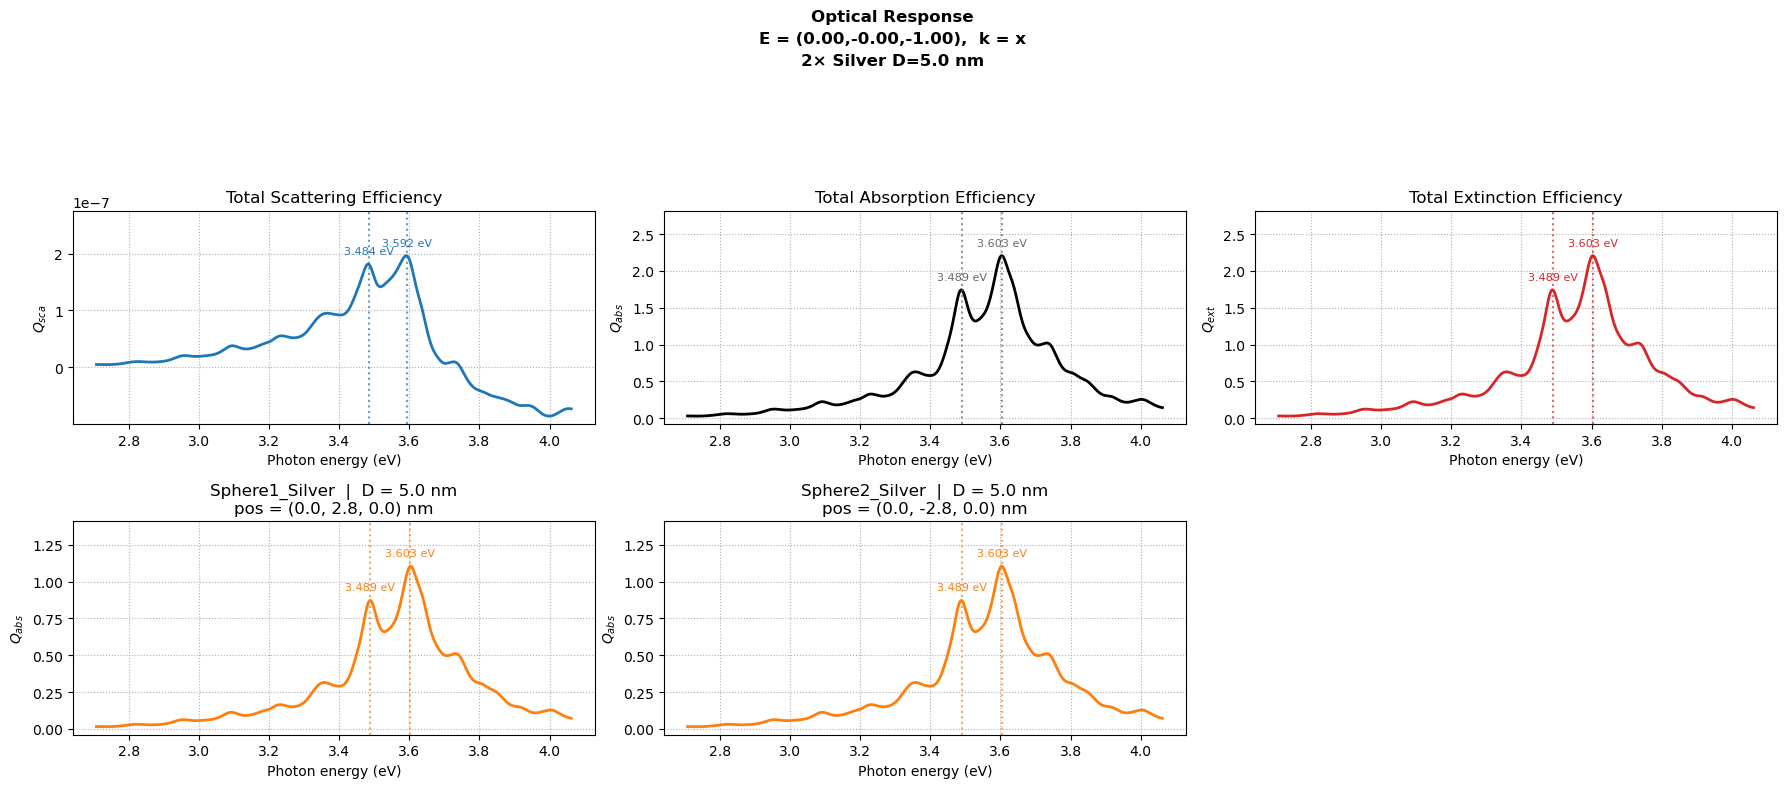

All figures and data saved in: results/dimer_D5.0nm_gap0.5nm_E(0.00,-0.00,-1.00)kx


In [3]:
import numpy as np

# Extract configuration from builder
positions, diameters, materials = builder.get_current_parameters()
k_vec = np.array([builder.k_x.value, builder.k_y.value, builder.k_z.value])
k_vec = k_vec / np.linalg.norm(k_vec)
e_vec = builder.compute_e_vector(k_vec, builder.pol_angle.value)
h_vec = np.cross(k_vec, e_vec)

# Configuration summary
print("=" * 70)
print("NANOCLUSTER CONFIGURATION SUMMARY")
print("=" * 70)
print(f"Number of particles: {len(positions)}")
print(f"\nIncident field:")
print(f"  k-vector:        [{k_vec[0]:.3f}, {k_vec[1]:.3f}, {k_vec[2]:.3f}]")
print(f"  Pol. angle:      {builder.pol_angle.value:.1f}°")
print(f"  E-vector:        [{e_vec[0]:.3f}, {e_vec[1]:.3f}, {e_vec[2]:.3f}]")
print(f"  H-vector (k×E): [{h_vec[0]:.3f}, {h_vec[1]:.3f}, {h_vec[2]:.3f}]")
print(f"\nParticles:")
for i, (pos, diam, mat) in enumerate(zip(positions, diameters, materials), 1):
    print(f"  {i}. {mat:12s}  D={diam:.1f} nm  pos=({pos[0]:.2f}, {pos[1]:.2f}, {pos[2]:.2f}) nm")
print("=" * 70)

# Ready for next process
config = {
    'positions':  positions,
    'diameters':  diameters,
    'materials':  materials,
    'k_vec':      k_vec,
    'e_vec':      e_vec,
    'h_vec':      h_vec,
    'pol_angle':  builder.pol_angle.value,
    'eps_h':      builder.medium_dropdown.value,
    'model':      builder.model_dropdown.value,  
}

from plytrons.bcm_sphere import run_optical_response
from plytrons.plot_utils import plot_optical_dashboard

results = run_optical_response(config, lmax=10)
plot_optical_dashboard(results, config=config)

BCM_objects           = results['BCM_objects']
efield                = results['efield']
w                     = results['w']
lam_um                = results['lam_um']
E_eV                  = results['E_eV']
eps_h                 = results['eps_h']
I0                    = results['I0']
Z0                    = results['Z0']
Psca                  = results['Psca']
Pabs                  = results['Pabs']
Qsca_total            = results['Qsca_total']
Qabs_total            = results['Qabs_total']
Qext_total            = results['Qext_total']
peak_idx_total        = results['peak_idx_total']
peak_idx_per_particle = results['peak_idx_per_particle']
outdir                = results['outdir']


In [46]:
import plytrons.quantum_well as qw

# ── Material-specific lattice parameters (fcc) ──
LATTICE = {
    'Silver': {'N_uc': 4, 'alat': 0.4086},
    'Gold':   {'N_uc': 4, 'alat': 0.4079},
    'Copper': {'N_uc': 4, 'alat': 0.3615},
}

# ── Compute QW states for each unique (material, diameter) ──
qw_data = {}

for mat, D in set(zip(config['materials'], config['diameters'])):
    a = D / 2.0
    lat = LATTICE[mat]

    print(f"\n{'─'*50}")
    print(f"QW states: {mat}, D = {D:.1f} nm")
    print(f"{'─'*50}")

    result = qw.compute_qw_states_with_occupations(
        a,
        D_nm=D,
        N_atoms_uc=lat['N_uc'],
        alat_nm=lat['alat'],
        desc=f"QW {mat} D={D:.1f}",
        show_progress=True,
    )

    E_matrix = result["E_matrix"]
    A_matrix = qw.get_normalization(a, E_matrix)
    e_states = qw.e_state_assembly(E_matrix, A_matrix)

    qw_data[(mat, D)] = {
        'e_states': e_states,
        'E_matrix': E_matrix,
        'A_matrix': A_matrix,
        'EF':       result["EF"],
        'Ne':       result["Ne"],
        'occ':      result["occ"],
        'f_occ':    result["f_occ"],
    }

    print(f"  Electrons: {result['Ne']}")
    print(f"  Fermi energy: {result['EF']:.3f} eV")

print(f"\nComputed QW states for {len(qw_data)} unique (material, diameter) pair(s)")



──────────────────────────────────────────────────
QW states: Silver, D = 15.0 nm
──────────────────────────────────────────────────


QW Silver D=15.0 a=7.500:   0%|          | 0/3 [00:00<?, ?step/s]

  Electrons: 103618
  Fermi energy: 5.653 eV

Computed QW states for 1 unique (material, diameter) pair(s)


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import binned_statistic
from plytrons.plot_utils import _collapse_equal_energies


def track_top_peaks(
    Mfi2, E_all, *,
    dedup="sum", tol=0.0,
    step=1,
    n_top=2,
    min_height_fraction=0.01,
    ref_idx=None,
    n_bins=40,
):
    M = np.asarray(Mfi2, float)
    E = np.asarray(E_all, float)

    order  = np.argsort(E)
    M_ord  = M[order][:, order]
    E_ord  = E[order]

    if dedup != "none":
        M_plot, E_u, _ = _collapse_equal_energies(M_ord, E_ord, how=dedup, tol=tol)
    else:
        M_plot, E_u = M_ord, E_ord

    records = []
    for idx in range(0, len(E_u), step):
        row  = M_plot[idx, :]
        E_i  = E_u[idx]
        rmax = row.max()
        if rmax == 0:
            continue
        pks, _ = find_peaks(row, height=rmax * min_height_fraction)
        if len(pks) == 0:
            pks = np.argsort(row)[-n_top:]

        # assign by sign: rank 0 = best positive ΔE, rank 1 = best negative ΔE
        for target_rank, sign in enumerate([1, -1]):
            candidates = [pk for pk in pks if sign * (E_u[pk] - E_i) > 0]
            if not candidates:
                continue
            # pick the one with highest Mfi2 among correct-sign candidates
            best = max(candidates, key=lambda pk: row[pk])
            records.append(dict(
                E_i  = float(E_i),
                E_f  = float(E_u[best]),
                val  = float(row[best]),
                dE   = float(E_u[best] - E_i),
                rank = target_rank,
            ))


    if not records:
        print("No peaks found.")
        return

    rec = np.array([(r["E_i"], r["E_f"], r["val"], r["dE"], r["rank"]) for r in records],
                   dtype=[("E_i","f8"),("E_f","f8"),("val","f8"),("dE","f8"),("rank","i4")])

    ranks  = np.unique(rec["rank"])
    colors = [plt.cm.tab10(rk / 10) for rk in ranks]

    # ── clip x-axis to where both peaks coexist ───────────────────────────
    # last E_i where peak 1 and peak 2 have opposite-sign ΔE
    from collections import defaultdict
    _ei_dE = defaultdict(dict)
    for r in rec:
        _ei_dE[r["E_i"]][int(r["rank"])] = r["dE"]

    _valid_ei = [ei for ei, d in sorted(_ei_dE.items())
                if 0 in d and 1 in d and d[0] * d[1] < 0]

    E_i_min = rec["E_i"].min()
    E_i_max = max(_valid_ei) if _valid_ei else rec["E_i"].max()
    print(f"Cutting at E_i = {E_i_max:.3f} eV (last point with opposite-sign peaks)")


    # ── reference row ─────────────────────────────────────────────────────
    all_idxs = list(range(0, len(E_u), step))
    ri = all_idxs[len(all_idxs) // 2] if ref_idx is None else ref_idx
    ref_row  = M_plot[ri, :]
    ref_Ei   = E_u[ri]
    ref_pks, _ = find_peaks(ref_row, height=ref_row.max() * min_height_fraction)
    if len(ref_pks) == 0:
        ref_pks = np.argsort(ref_row)[-n_top:]
    ref_pks = ref_pks[np.argsort(ref_row[ref_pks])[::-1]][:n_top]

    # ── binned statistics (only within shared E_i range) ─────────────────
    E_range = (E_i_min, E_i_max)
    bin_stats = {}
    for rk, col in zip([0, 1], ["tab:blue", "tab:orange"]):
        mask = (rec["rank"] == rk) & (rec["E_i"] <= E_i_max)
        Ei, dE = rec["E_i"][mask], rec["dE"][mask]
        mean,  edges, _ = binned_statistic(Ei, dE, statistic="mean",  bins=n_bins, range=E_range)
        std,   _,     _ = binned_statistic(Ei, dE, statistic="std",   bins=n_bins, range=E_range)
        count, _,     _ = binned_statistic(Ei, dE, statistic="count", bins=n_bins, range=E_range)
        centers = 0.5 * (edges[:-1] + edges[1:])
        valid   = count > 2
        bin_stats[rk] = dict(centers=centers, mean=mean, std=std, valid=valid, color=col)

    valid_both = bin_stats[0]["valid"] & bin_stats[1]["valid"]
    gap        = bin_stats[0]["mean"] - bin_stats[1]["mean"]
    ctrs       = bin_stats[0]["centers"]
    p_gap      = np.polyfit(ctrs[valid_both], gap[valid_both], 1)

    fits_std = {}
    for rk in [0, 1]:
        v = bin_stats[rk]["valid"]
        p = np.polyfit(ctrs[v], bin_stats[rk]["std"][v], 1)
        fits_std[rk] = (p, np.polyval(p, ctrs[v]))

    # ── 2×3 figure ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)

    # [0,0] — E_f vs E_i
    ax = axes[0, 0]
    for rk, col in zip(ranks, colors):
        mask = (rec["rank"] == rk) & (rec["E_i"] <= E_i_max)
        ax.scatter(rec["E_i"][mask], rec["E_f"][mask], s=6, alpha=0.6, color=col, label=f"peak {rk+1}")
    ax.plot([E_i_min, E_i_max], [E_i_min, E_i_max], "gray", lw=1, ls="--")
    ax.set_xlim(E_i_min, E_i_max)
    ax.set_xlabel("$E_i$ (eV)"); ax.set_ylabel("$E_f$ (eV)")
    ax.set_title("Peak $E_f$ vs $E_i$"); ax.legend(fontsize=7, markerscale=2); ax.grid(True, alpha=0.3)

    # [0,1] — ΔE vs E_i
    ax = axes[0, 1]
    for rk, col in zip(ranks, colors):
        mask = (rec["rank"] == rk) & (rec["E_i"] <= E_i_max)
        ax.scatter(rec["E_i"][mask], rec["dE"][mask], s=6, alpha=0.6, color=col, label=f"peak {rk+1}")
    ax.axhline(0, color="gray", lw=1, ls="--")
    ax.set_xlim(E_i_min, E_i_max)
    ax.set_xlabel("$E_i$ (eV)"); ax.set_ylabel(r"$\Delta E$ (eV)")
    ax.set_title(r"Peak $\Delta E$ vs $E_i$"); ax.legend(fontsize=7, markerscale=2); ax.grid(True, alpha=0.3)

    # [0,2] — reference row
    ax = axes[0, 2]
    ax.scatter(E_u, ref_row, s=4, color="steelblue", alpha=0.5, label="$M_{fi}^2$")
    for rank, pk in enumerate(ref_pks):
        col = plt.cm.tab10(rank / 10)
        ax.axvline(E_u[pk], color=col, lw=1.2, ls="--", alpha=0.8)
        ax.scatter(E_u[pk], ref_row[pk], s=60, zorder=5, color=col,
                   label=f"peak {rank+1}: $E_f$={E_u[pk]:.3f} eV")
    ax.axvline(ref_Ei, color="white", lw=1, ls=":", alpha=0.6, label=f"$E_i$={ref_Ei:.3f} eV")
    ax.set_yscale("log"); ax.set_xlabel("$E_f$ (eV)"); ax.set_ylabel("$M_{fi}^2$")
    ax.set_title(f"Reference row: $E_i$={ref_Ei:.3f} eV (idx={ri})")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3, which="both")

    # [1,0] — mean ΔE ± 1σ
    ax = axes[1, 0]
    for rk in [0, 1]:
        s, v = bin_stats[rk], bin_stats[rk]["valid"]
        ax.plot(s["centers"][v], s["mean"][v], color=s["color"], lw=2, label=f"peak {rk+1}")
        ax.fill_between(s["centers"][v], s["mean"][v]-s["std"][v], s["mean"][v]+s["std"][v],
                        color=s["color"], alpha=0.2)
    ax.axhline(0, color="gray", lw=1, ls="--")
    ax.set_xlim(E_i_min, E_i_max)
    ax.set_xlabel("$E_i$ (eV)"); ax.set_ylabel(r"mean $\Delta E$ (eV)")
    ax.set_title(r"Mean $\Delta E$ ± 1$\sigma$"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # [1,1] — gap between means
    ax = axes[1, 1]
    ax.scatter(ctrs[valid_both], gap[valid_both], s=15, color="mediumpurple", zorder=3)
    ax.plot(ctrs[valid_both], np.polyval(p_gap, ctrs[valid_both]), "k--", lw=1.5,
            label=f"fit: {p_gap[0]:.4f}·$E_i$ + {p_gap[1]:.4f} eV")
    ax.set_xlim(E_i_min, E_i_max)
    ax.set_xlabel("$E_i$ (eV)"); ax.set_ylabel(r"$\langle\Delta E\rangle_1 - \langle\Delta E\rangle_2$ (eV)")
    ax.set_title("Gap between peak means"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # [1,2] — dispersion σ
    ax = axes[1, 2]
    for rk in [0, 1]:
        s, v = bin_stats[rk], bin_stats[rk]["valid"]
        p, f = fits_std[rk]
        ax.scatter(s["centers"][v], s["std"][v], s=15, color=s["color"], zorder=3, label=f"peak {rk+1}")
        ax.plot(s["centers"][v], f, color=s["color"], lw=1.5, ls="--",
                label=f"  {p[0]:.5f}·$E_i$ + {p[1]:.5f}")
    ax.set_xlim(E_i_min, E_i_max)
    ax.set_xlabel("$E_i$ (eV)"); ax.set_ylabel(r"$\sigma(\Delta E)$ (eV)")
    ax.set_title(r"Dispersion $\sigma$ per peak"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    plt.show()

    print(f"Both peaks present up to E_i = {E_i_max:.3f} eV")
    print(f"Gap slope:     {p_gap[0]:.5f} eV/eV  ({p_gap[0]*1e3:.2f} meV per eV of E_i)")
    print(f"Gap intercept: {p_gap[1]:.5f} eV")
    for rk in [0, 1]:
        p, _ = fits_std[rk]
        print(f"peak {rk+1} σ slope: {p[0]:.5f} eV/eV  intercept: {p[1]:.5f} eV")

    return rec


###################################################################
  Nanoparticle number 1  (Silver, D=15.0 nm, EF=5.65 eV)
###################################################################

Resonance peak number 1
Wavelength at peak absorption: 339.97 nm
Photon energy: 3.65 eV
Absorption power at peak: 137885.53 eV/ps
-------------------------------------------------------
P_diss (eV/fs) = 489.5557195565927
Pabs (your units) = 137885.53322542462
S = 281.65442199370534


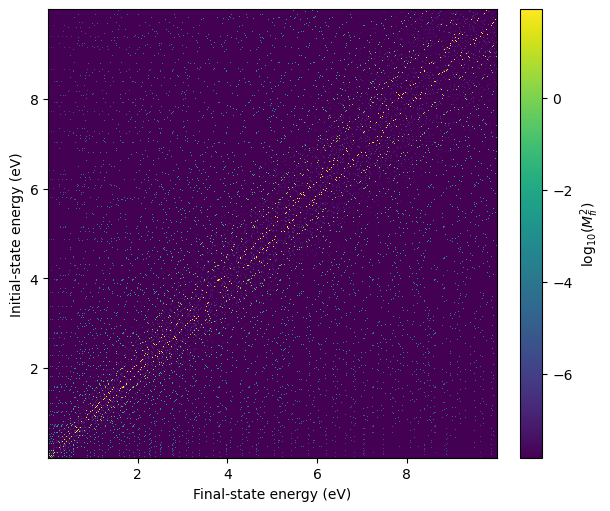

Cutting at E_i = 9.805 eV (last point with opposite-sign peaks)


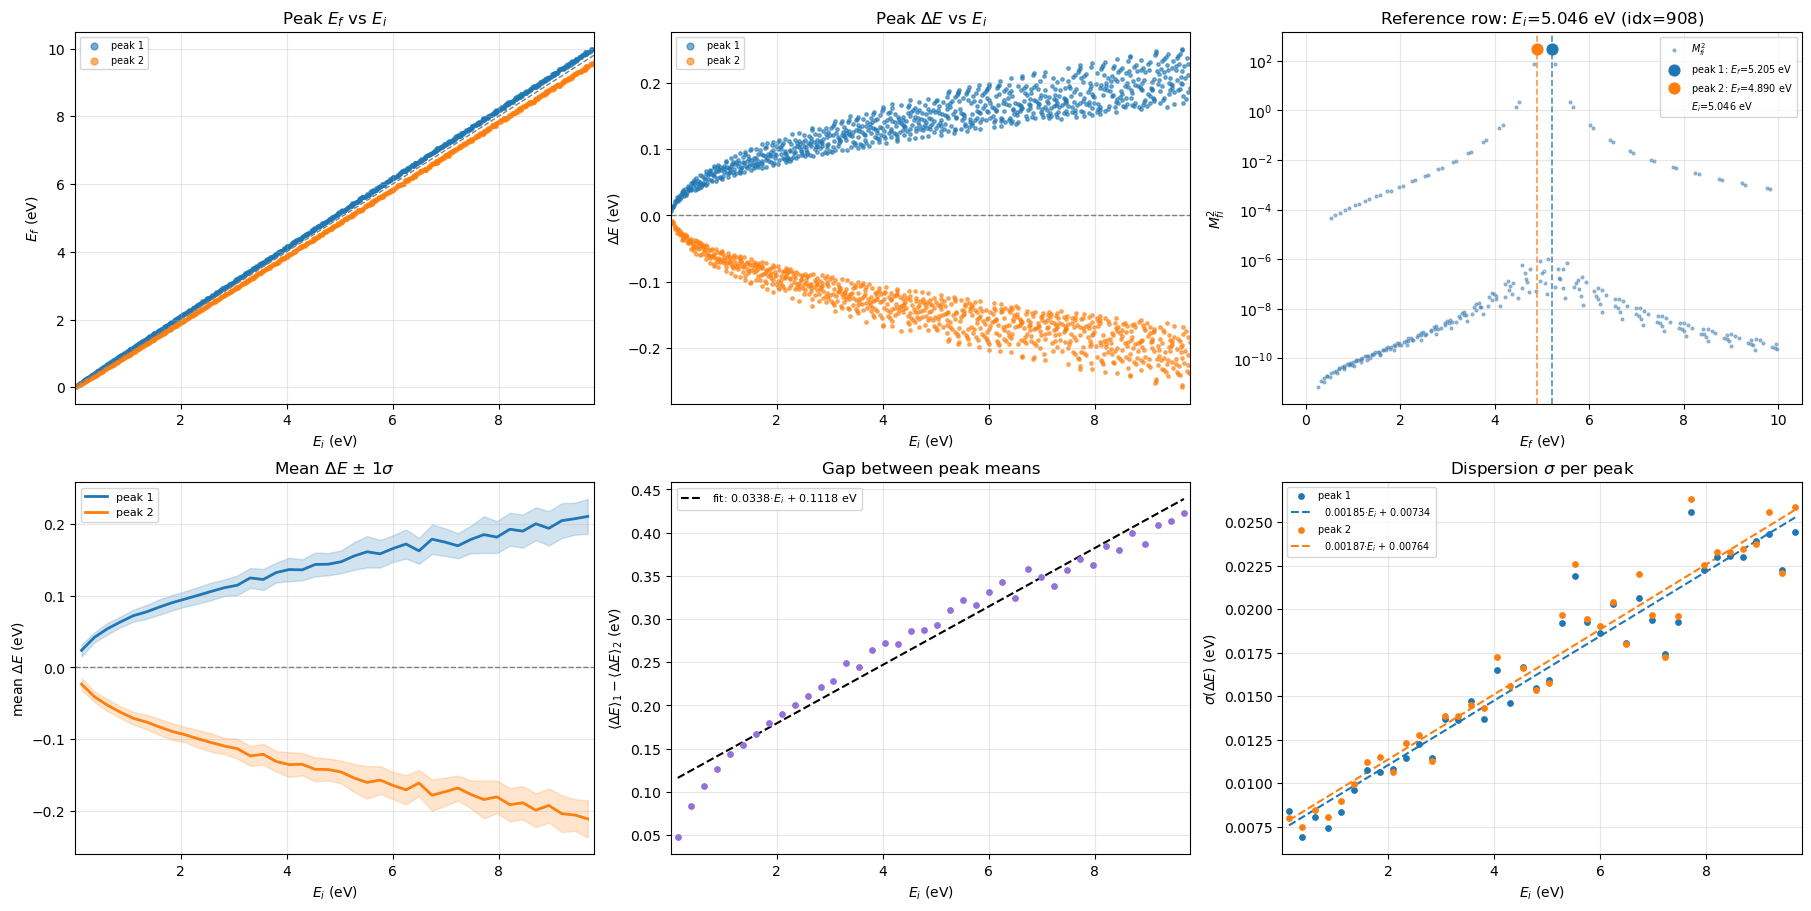

Both peaks present up to E_i = 9.805 eV
Gap slope:     0.03379 eV/eV  (33.79 meV per eV of E_i)
Gap intercept: 0.11177 eV
peak 1 σ slope: 0.00185 eV/eV  intercept: 0.00734 eV
peak 2 σ slope: 0.00187 eV/eV  intercept: 0.00764 eV
peak 1:  mean ΔE = 0.2055 eV  (std=0.0244 eV,  n=80)
peak 2:  mean ΔE = -0.2058 eV  (std=0.0257 eV,  n=100)


In [51]:
import numpy as np
from scipy.constants import hbar, eV
from plytrons.hot_carriers import hot_e_dist, hot_e_cdf_per_photon, count_eh_generated
import warnings
from numba.core.errors import NumbaTypeSafetyWarning
warnings.simplefilter("ignore", category=NumbaTypeSafetyWarning)
from plytrons.math_utils import eps0
from plytrons.plot_utils import (
    plot_transition_matrix_colormap,
    plot_Ne_cdf_steps,
    hot_carrier_dynamics_plot,
    hot_carriers_plot
)

# ----------------------------------- Simulation setup -----------------------------------
tau_e = np.linspace(50, 1500, 59)
plot_flag = 'static'                                # 'static' | 'dynamics' | 'both'

tau       = 500                                   # static snapshot lifetime (fs)
dE_factor = 5
delta     = 4.0
idx       = np.abs(tau_e - tau).argmin()
# ----------------------------------------------------------------------------------------

for Np in range(len(BCM_objects)):

    # ── per-particle QW data ──
    mat = config['materials'][Np]
    D   = config['diameters'][Np]
    a   = D / 2.0
    qw  = qw_data[(mat, D)]
    e_states = qw['e_states']
    EF       = qw['EF']

    peaks_pos = peak_idx_per_particle[Np]

    print('')
    print('###################################################################')
    print(f'  Nanoparticle number {Np+1}  ({mat}, D={D:.1f} nm, EF={EF:.2f} eV)')
    print('###################################################################')
    print('')


    lam_target = lam_um[peaks_pos[0]]
    hv         = 2*np.pi*3E14 / lam_target * hbar / eV
    Pabs_peak  = Pabs[Np][peaks_pos[0]] / (np.pi * eps0) * 1e-15
    X_lm       = BCM_objects[Np].coef_at(lam_target)

    print(f'Resonance peak number {0+1}')
    print(f'Wavelength at peak absorption: {lam_target*1e3:.2f} nm')
    print(f'Photon energy: {hv:.2f} eV')
    print(f'Absorption power at peak: {Pabs_peak:.2f} eV/ps')
    print('-------------------------------------------------------')

    Te, Th, Te_raw, Th_raw, Mfi2, E_vals, S, Pabs_out, P_diss = hot_e_dist(
        a, hv, EF, tau_e, e_states, X_lm, Pabs_peak
    )

    print("P_diss (eV/fs) =", P_diss)
    print("Pabs (your units) =", Pabs_out)
    print("S =", S)


    plot_transition_matrix_colormap(
        Mfi2, E_vals,
        dedup="sum", scale="log", qmin=0.95, qmax=0.999
    )

    rec = track_top_peaks(
    Mfi2, E_vals,
    dedup="sum",
    step=2,
    n_top=2,
    min_height_fraction=0.01,
    )
    
    # mean ΔE of the top 10% of E_i values for each peak
    cutoff = np.percentile(rec["E_i"], 90)
    for rk, label in [(0, "peak 1"), (1, "peak 2")]:
        mask = (rec["rank"] == rk) & (rec["E_i"] >= cutoff)
        vals = rec["dE"][mask]
        print(f"{label}:  mean ΔE = {vals.mean():.4f} eV  (std={vals.std():.4f} eV,  n={mask.sum()})")




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LogNorm
from plytrons.plot_utils import _collapse_equal_energies, _edges_from_centers


def mfi2_gif(
    Mfi2, E_all, *,
    dedup="sum", tol=0.0,
    fps=10,
    step=1,
    out_path="mfi2_vs_Ef.gif",
):
    M = np.asarray(Mfi2, float)
    E = np.asarray(E_all, float)

    order  = np.argsort(E)
    M_ord  = M[order][:, order]
    E_ord  = E[order]

    if dedup != "none":
        M_plot, E_u, _ = _collapse_equal_energies(M_ord, E_ord, how=dedup, tol=tol)
    else:
        M_plot, E_u = M_ord, E_ord

    indices = np.arange(0, len(E_u), step)
    edges   = _edges_from_centers(E_u)

    # ── scatter panel norms ───────────────────────────────────────────────
    vmin = M_plot[M_plot > 0].min()
    vmax = M_plot.max()
    norm = LogNorm(vmin=vmin, vmax=vmax)
    ymin, ymax = vmin * 0.5, vmax * 2

    # ── matrix panel norms + masked colormap ─────────────────────────────
    mat_vmin = np.percentile(M_plot[M_plot > 0], 90)
    mat_vmax = np.percentile(M_plot[M_plot > 0], 100)
    mat_norm = LogNorm(vmin=mat_vmin, vmax=mat_vmax)

    cmap_mat = plt.cm.inferno.copy()
    cmap_mat.set_bad("black")
    cmap_mat.set_under("black")

    M_masked = np.ma.masked_where(M_plot <= 0, M_plot)

    # ── figure ────────────────────────────────────────────────────────────
    fig, (ax_sc, ax_mat) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

    # scatter panel
    sc = ax_sc.scatter([], [], s=15, cmap="inferno", norm=norm, zorder=5)
    vl = ax_sc.axvline(0, color="cyan", lw=1.2, ls="--")
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="inferno"),
                 ax=ax_sc, label=r"$M_{fi}^2$")
    ax_sc.set_xlim(E_u[0], E_u[-1])
    ax_sc.set_ylim(ymin, ymax)
    ax_sc.set_yscale("log")
    ax_sc.set_xlabel("$E_f$ (eV)")
    ax_sc.set_ylabel(r"$M_{fi}^2$")
    ax_sc.grid(True, alpha=0.3)

    # matrix panel
    ax_mat.pcolormesh(edges, edges, M_masked.T,
                      norm=mat_norm, cmap=cmap_mat, shading="flat")
    fig.colorbar(plt.cm.ScalarMappable(norm=mat_norm, cmap=cmap_mat),
                 ax=ax_mat, label=r"$M_{fi}^2$")
    hl = ax_mat.axhline(E_u[0], color="cyan", lw=1.2, ls="--")
    ax_mat.set_xlabel("$E_i$ (eV)")
    ax_mat.set_ylabel("$E_f$ (eV)")
    ax_mat.set_title("Transition matrix")
    ax_mat.set_xlim(edges[0], edges[-1])
    ax_mat.set_ylim(edges[0], edges[-1])

    def update(frame_idx):
        idx = indices[frame_idx]
        row = M_plot[idx, :]
        E_i = E_u[idx]

        sc.set_offsets(np.column_stack([E_u, row]))
        sc.set_array(row)
        vl.set_xdata([E_i, E_i])
        ax_sc.set_title(rf"$M_{{fi}}^2$ vs $E_f$  |  $E_i$ = {E_i:.3f} eV")

        hl.set_ydata([E_i, E_i])

        return sc, vl, hl

    anim = FuncAnimation(fig, update, frames=len(indices), blit=False, interval=1000 // fps)
    anim.save(out_path, writer=PillowWriter(fps=fps))
    plt.close(fig)
    print(f"Saved: {out_path}")

    try:
        from IPython.display import Image, display
        display(Image(filename=out_path))
    except Exception:
        pass


mfi2_gif(
    Mfi2, E_vals,
    dedup="sum",
    fps=5,
    step=5,
    out_path="mfi2_vs_Ef.gif",
)


/tmp/ipykernel_8767/3571952427.py:51: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored




  D = 5 nm
Surrounding medium: Vacuum / Air  (εₕ = 1.0)
Auto energy range: 2.71 – 4.06 eV
  Silver: resonance ≈ 3.38 eV
Dielectric model: Bulk


Assembling Gi/G0/Sv:   0%|          | 0/1 [00:00<?, ?obj/s]

Solving BCM over ω:   0%|          | 0/500 [00:00<?, ?pt/s]

Absorption peaks: 1  at λ = 340.0 nm
Saving to: results/monomer-single_D5.0nm_isolated_Exkz


/home/pablo/plytrons/plytrons/bcm_sphere.py:252: RuntimeWarning:

invalid value encountered in true_divide



...

Surrounding medium: Vacuum / Air  (εₕ = 1.0)
Auto energy range: 2.71 – 4.06 eV
  Silver: resonance ≈ 3.38 eV
  Silver: resonance ≈ 3.38 eV
Dielectric model: Bulk


Assembling Gi/G0/Sv:   0%|          | 0/2 [00:00<?, ?obj/s]

Solving BCM over ω:   0%|          | 0/500 [00:00<?, ?pt/s]

Absorption peaks: 3  at λ = 401.5 nm, 345.9 nm, 329.9 nm
Saving to: results/dimer_D20.0nm_gap1.0nm_Exkz


/home/pablo/plytrons/plytrons/bcm_sphere.py:252: RuntimeWarning:

invalid value encountered in true_divide



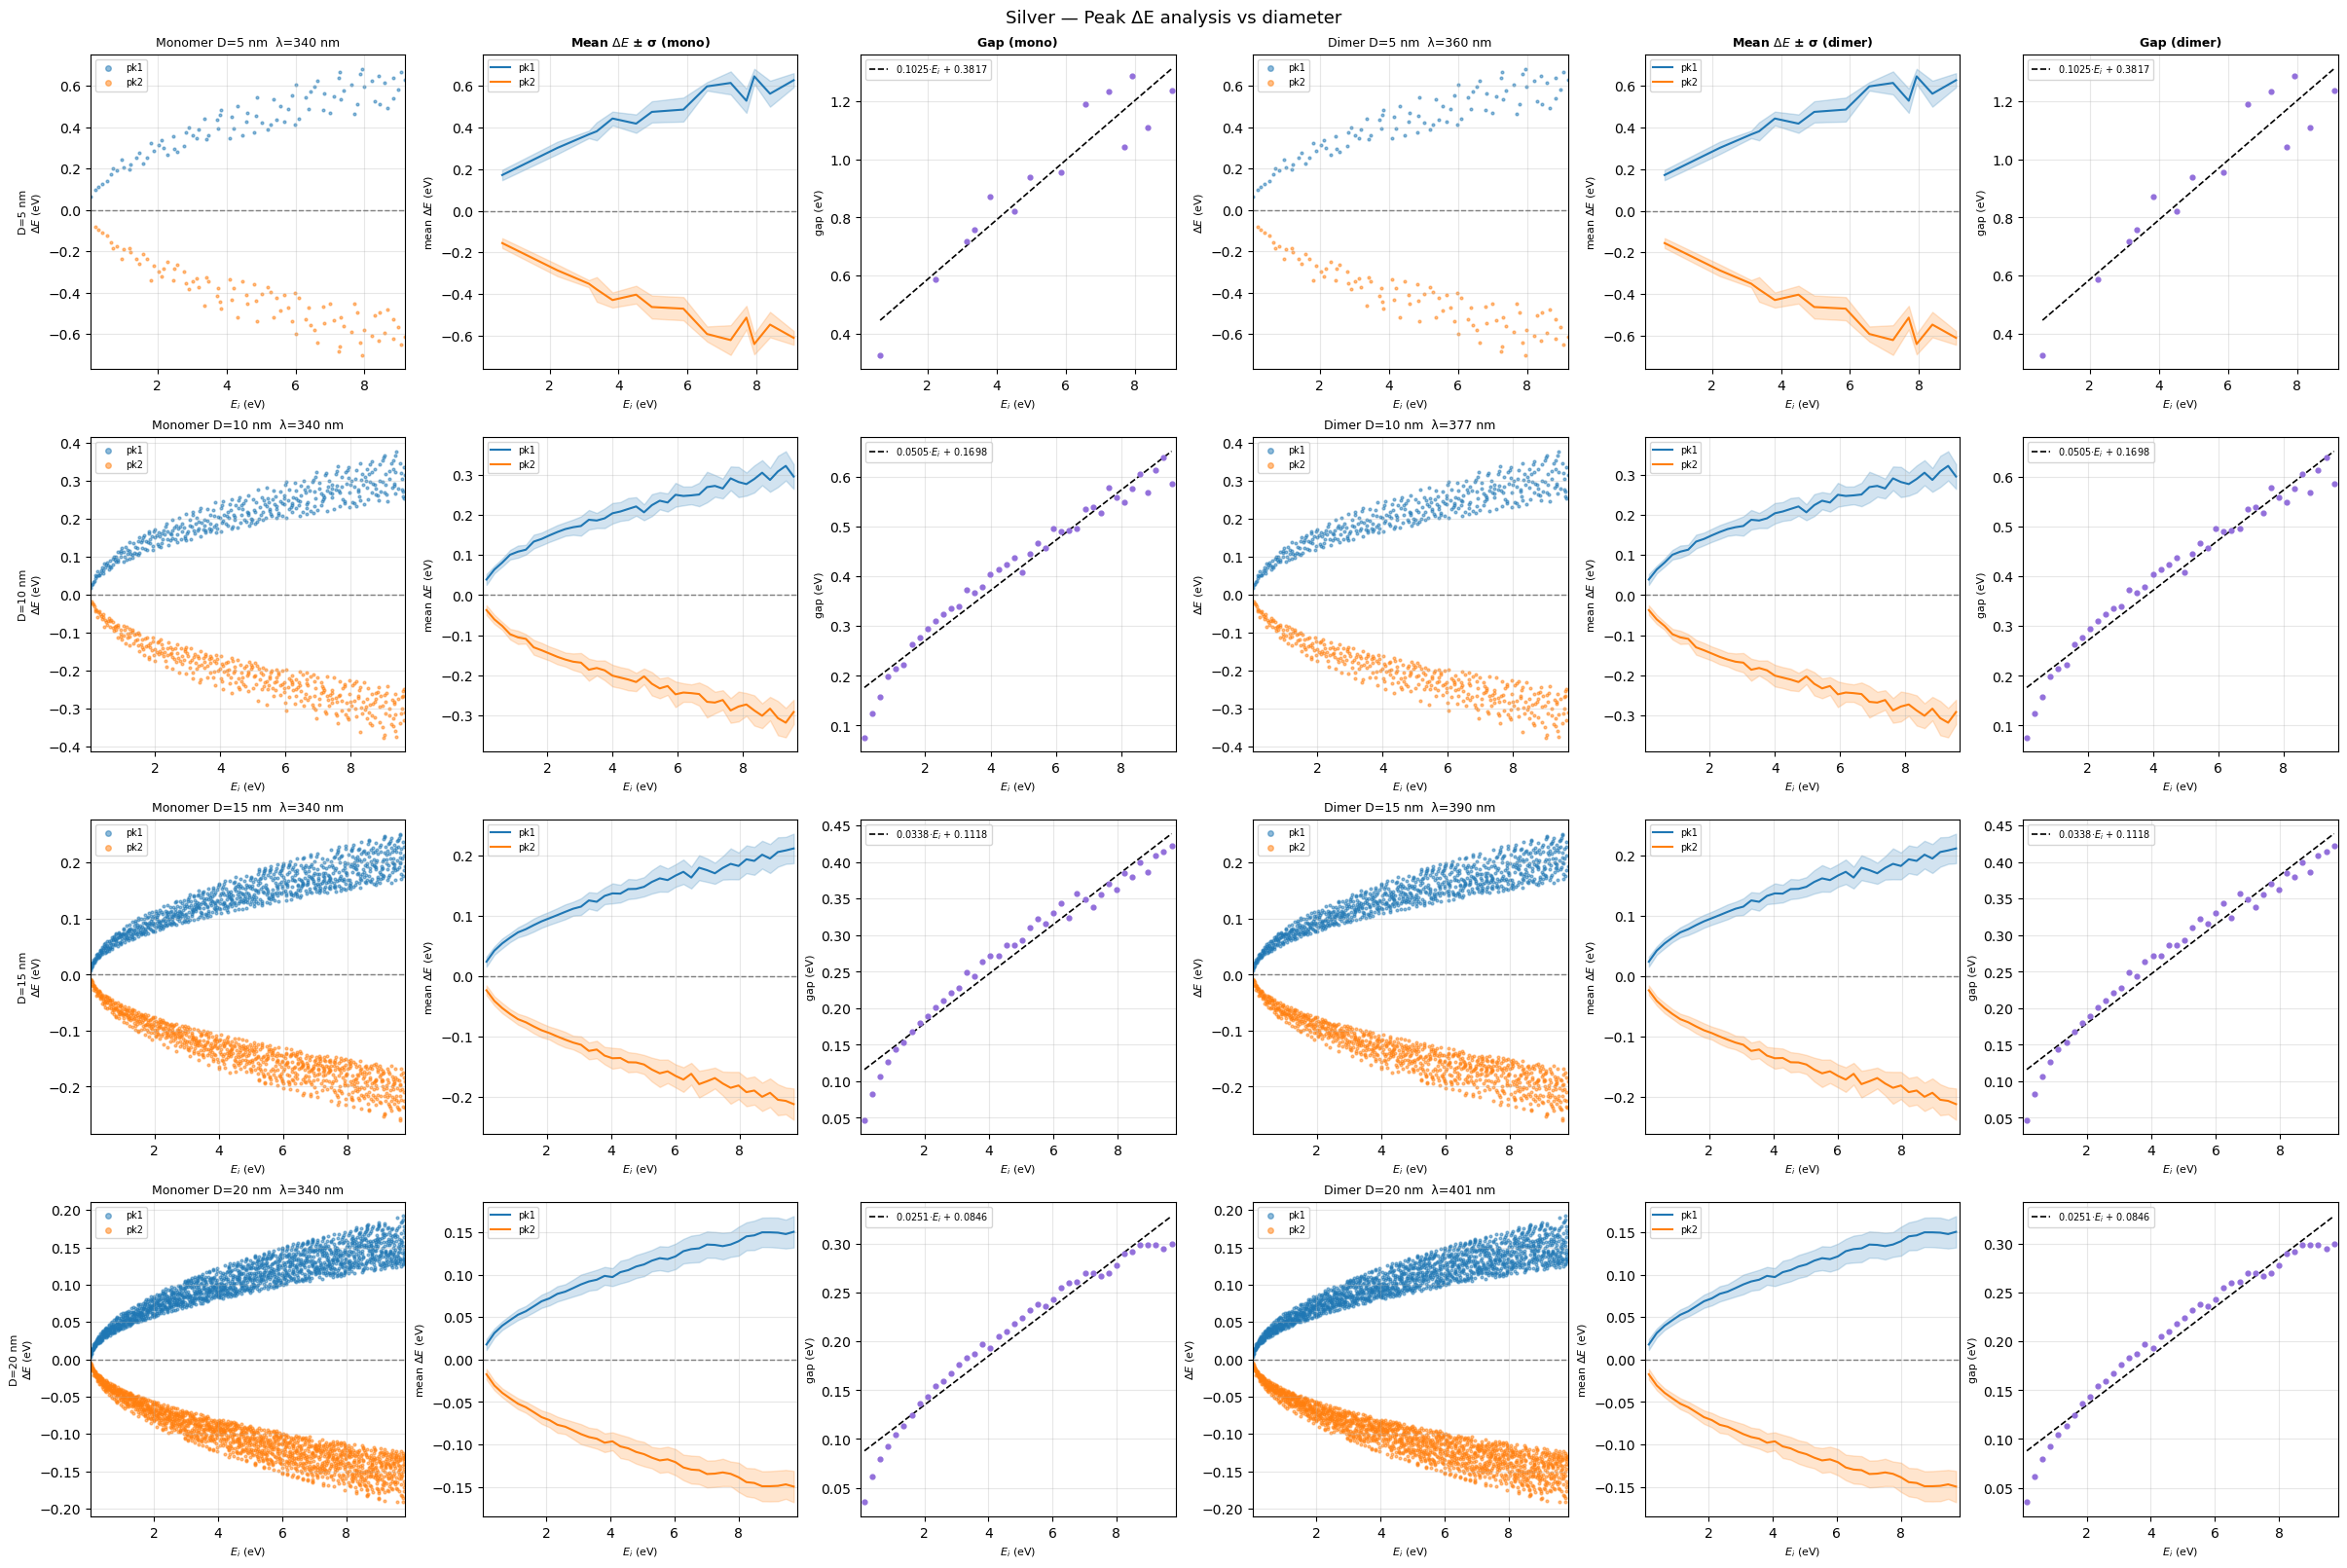

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from collections import defaultdict
from scipy.signal import find_peaks
from scipy.stats import binned_statistic
from numba.core.errors import NumbaTypeSafetyWarning
warnings.simplefilter("ignore", category=NumbaTypeSafetyWarning)

import plytrons.quantum_well as qw
from plytrons.bcm_sphere import run_optical_response
from plytrons.hot_carriers import hot_e_dist
from plytrons.plot_utils import _collapse_equal_energies
from plytrons.math_utils import eps0
from scipy.constants import hbar, eV

# ── settings ──────────────────────────────────────────────────────────────────
DIAMETERS  = [5, 10, 15, 20]       # nm
MATERIAL   = "Silver"
LATTICE    = {'N_uc': 4, 'alat': 0.4086}
tau_e      = np.linspace(50, 1500, 59)
tau        = 500
k_vec      = np.array([0., 0., 1.])
e_vec      = np.array([1., 0., 0.])

# ── helper: build config dict ─────────────────────────────────────────────────
def make_config(positions, diameters):
    return dict(
        positions  = positions,
        diameters  = diameters,
        materials  = [MATERIAL] * len(diameters),
        k_vec      = k_vec,
        e_vec      = e_vec,
        h_vec      = np.cross(k_vec, e_vec),
        pol_angle  = 0.0,
        eps_h      = "Vacuum / Air",   # <-- was 1.0
        model      = "Bulk",
    )


# ── helper: QW states ─────────────────────────────────────────────────────────
def get_qw(D):
    a = D / 2.0
    res = qw.compute_qw_states_with_occupations(
        a, D_nm=D, N_atoms_uc=LATTICE['N_uc'], alat_nm=LATTICE['alat'],
        desc=f"D={D}", show_progress=False,
    )
    E_mat = res["E_matrix"]
    A_mat = qw.get_normalization(a, E_mat)
    return qw.e_state_assembly(E_mat, A_mat), res["EF"]

# ── helper: run hot_e_dist at resonance ───────────────────────────────────────
def get_Mfi2(D, positions, e_states, EF):
    config  = make_config(positions, [D] * len(positions))
    results = run_optical_response(config, lmax=10)
    BCM_obj = results['BCM_objects'][0]
    lam_um  = results['lam_um']
    Pabs    = results['Pabs'][0]

    # pick first resonance peak of particle 0
    pk_idx  = results['peak_idx_per_particle'][0][0]
    lam_res = lam_um[pk_idx]
    hv      = 2 * np.pi * 3e14 / lam_res * hbar / eV
    Pabs_pk = Pabs[pk_idx] / (np.pi * eps0) * 1e-15
    X_lm    = BCM_obj.coef_at(lam_res)

    a = D / 2.0
    _, _, _, _, Mfi2, E_vals, *_ = hot_e_dist(a, hv, EF, tau_e, e_states, X_lm, Pabs_pk)
    return Mfi2, E_vals, hv, lam_res * 1e3

# ── helper: track peaks and return bin_stats + E_i_max ───────────────────────
def run_peak_analysis(Mfi2, E_vals, step=2, n_top=2, mhf=0.01, n_bins=40):
    M = np.asarray(Mfi2, float)
    E = np.asarray(E_vals, float)
    order  = np.argsort(E)
    M_ord  = M[order][:, order]
    E_ord  = E[order]
    M_plot, E_u, _ = _collapse_equal_energies(M_ord, E_ord, how="sum")

    records = []
    for idx in range(0, len(E_u), step):
        row  = M_plot[idx, :]
        E_i  = E_u[idx]
        rmax = row.max()
        if rmax == 0:
            continue
        pks, _ = find_peaks(row, height=rmax * mhf)
        if len(pks) == 0:
            pks = np.argsort(row)[-n_top:]
        for target_rank, sign in enumerate([1, -1]):
            cands = [pk for pk in pks if sign * (E_u[pk] - E_i) > 0]
            if not cands:
                continue
            best = max(cands, key=lambda pk: row[pk])
            records.append(dict(E_i=float(E_i), E_f=float(E_u[best]),
                                val=float(row[best]), dE=float(E_u[best] - E_i),
                                rank=target_rank))

    if not records:
        return None, None, None

    rec = np.array([(r["E_i"], r["E_f"], r["val"], r["dE"], r["rank"]) for r in records],
                   dtype=[("E_i","f8"),("E_f","f8"),("val","f8"),("dE","f8"),("rank","i4")])

    # sign-based E_i_max
    _ei_dE = defaultdict(dict)
    for r in rec:
        _ei_dE[r["E_i"]][int(r["rank"])] = r["dE"]
    valid_ei = [ei for ei, d in sorted(_ei_dE.items())
                if 0 in d and 1 in d and d[0] * d[1] < 0]
    E_i_max = max(valid_ei) if valid_ei else rec["E_i"].max()

    E_range = (rec["E_i"].min(), E_i_max)
    bin_stats = {}
    for rk, col in zip([0, 1], ["tab:blue", "tab:orange"]):
        mask = (rec["rank"] == rk) & (rec["E_i"] <= E_i_max)
        Ei, dE = rec["E_i"][mask], rec["dE"][mask]
        if len(Ei) < 3:
            continue
        mean,  edges, _ = binned_statistic(Ei, dE, statistic="mean",  bins=n_bins, range=E_range)
        std,   _,     _ = binned_statistic(Ei, dE, statistic="std",   bins=n_bins, range=E_range)
        count, _,     _ = binned_statistic(Ei, dE, statistic="count", bins=n_bins, range=E_range)
        centers = 0.5 * (edges[:-1] + edges[1:])
        bin_stats[rk] = dict(centers=centers, mean=mean, std=std,
                             valid=count > 2, color=col)
    return rec, bin_stats, E_i_max

# ── draw 6-panel row into axes[row_idx] ──────────────────────────────────────
def draw_row(axes, rec, bin_stats, E_i_max, title):
    colors = ["tab:blue", "tab:orange"]

    # [0] ΔE vs E_i
    ax = axes[0]
    for rk, col in enumerate(colors):
        mask = (rec["rank"] == rk) & (rec["E_i"] <= E_i_max)
        ax.scatter(rec["E_i"][mask], rec["dE"][mask], s=4, alpha=0.5, color=col,
                   label=f"pk{rk+1}")
    ax.axhline(0, color="gray", lw=1, ls="--")
    ax.set_xlim(rec["E_i"].min(), E_i_max)
    ax.set_ylabel(r"$\Delta E$ (eV)", fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7, markerscale=2)
    ax.grid(True, alpha=0.3)

    # [1] mean ΔE ± 1σ
    ax = axes[1]
    for rk in [0, 1]:
        if rk not in bin_stats:
            continue
        s, v = bin_stats[rk], bin_stats[rk]["valid"]
        ax.plot(s["centers"][v], s["mean"][v], color=s["color"], lw=1.5, label=f"pk{rk+1}")
        ax.fill_between(s["centers"][v], s["mean"][v]-s["std"][v],
                        s["mean"][v]+s["std"][v], color=s["color"], alpha=0.2)
    ax.axhline(0, color="gray", lw=1, ls="--")
    ax.set_xlim(rec["E_i"].min(), E_i_max)
    ax.set_ylabel(r"mean $\Delta E$ (eV)", fontsize=8)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # [2] gap
    if 0 in bin_stats and 1 in bin_stats:
        vb = bin_stats[0]["valid"] & bin_stats[1]["valid"]
        gap = bin_stats[0]["mean"] - bin_stats[1]["mean"]
        ctrs = bin_stats[0]["centers"]
        if vb.sum() > 2:
            p = np.polyfit(ctrs[vb], gap[vb], 1)
            axes[2].scatter(ctrs[vb], gap[vb], s=12, color="mediumpurple", zorder=3)
            axes[2].plot(ctrs[vb], np.polyval(p, ctrs[vb]), "k--", lw=1.2,
                         label=f"{p[0]:.4f}·$E_i$ + {p[1]:.4f}")
            axes[2].legend(fontsize=7)
    axes[2].set_xlim(rec["E_i"].min(), E_i_max)
    axes[2].set_ylabel(r"gap (eV)", fontsize=8)
    axes[2].grid(True, alpha=0.3)

    for ax in axes:
        ax.set_xlabel("$E_i$ (eV)", fontsize=8)

# ══════════════════════════════════════════════════════════════════════════════
# MAIN SWEEP
# ══════════════════════════════════════════════════════════════════════════════
fig, axes_all = plt.subplots(
    len(DIAMETERS), 6,
    figsize=(24, 4 * len(DIAMETERS)),
    constrained_layout=True,
)
fig.suptitle(f"{MATERIAL} — Peak ΔE analysis vs diameter", fontsize=13)

col_titles = ["ΔE vs $E_i$ (mono)", r"Mean $\Delta E$ ± σ (mono)", "Gap (mono)",
              "ΔE vs $E_i$ (dimer)", r"Mean $\Delta E$ ± σ (dimer)", "Gap (dimer)"]
for j, ct in enumerate(col_titles):
    axes_all[0, j].set_title(ct, fontsize=9, fontweight="bold")

for row_i, D in enumerate(DIAMETERS):
    print(f"\n{'='*60}")
    print(f"  D = {D} nm")
    print(f"{'='*60}")

    e_states, EF = get_qw(D)

    # ── monomer ──────────────────────────────────────────────────────────
    pos_mono = [np.array([0., 0., 0.])]
    Mfi2_m, E_m, hv_m, lam_m = get_Mfi2(D, pos_mono, e_states, EF)
    rec_m, bs_m, eimax_m = run_peak_analysis(Mfi2_m, E_m)
    if rec_m is not None:
        draw_row(axes_all[row_i, :3], rec_m, bs_m, eimax_m,
                 f"Monomer D={D} nm  λ={lam_m:.0f} nm")

    # ── dimer (gap = 1 nm) ────────────────────────────────────────────────
    gap_nm = 1.0
    sep    = D / 2 + gap_nm / 2
    pos_dim = [np.array([-sep, 0., 0.]), np.array([sep, 0., 0.])]
    Mfi2_d, E_d, hv_d, lam_d = get_Mfi2(D, pos_dim, e_states, EF)
    rec_d, bs_d, eimax_d = run_peak_analysis(Mfi2_d, E_d)
    if rec_d is not None:
        draw_row(axes_all[row_i, 3:], rec_d, bs_d, eimax_d,
                 f"Dimer D={D} nm  λ={lam_d:.0f} nm")

    # row label
    axes_all[row_i, 0].set_ylabel(f"D={D} nm\n" + r"$\Delta E$ (eV)", fontsize=8)

plt.show()


D = 5 nm ... Surrounding medium: Vacuum / Air  (εₕ = 1.0)
Auto energy range: 2.71 – 4.06 eV
  Silver: resonance ≈ 3.38 eV
Dielectric model: Bulk


Assembling Gi/G0/Sv:   0%|          | 0/1 [00:00<?, ?obj/s]

Solving BCM over ω:   0%|          | 0/500 [00:00<?, ?pt/s]

Absorption peaks: 1  at λ = 340.0 nm
Saving to: results/monomer-single_D5.0nm_isolated_Exkz


/home/pablo/plytrons/plytrons/bcm_sphere.py:252: RuntimeWarning:

invalid value encountered in true_divide



...

Assembling Gi/G0/Sv:   0%|          | 0/2 [00:00<?, ?obj/s]

Solving BCM over ω:   0%|          | 0/500 [00:00<?, ?pt/s]

Absorption peaks: 3  at λ = 401.5 nm, 345.9 nm, 329.9 nm
Saving to: results/dimer_D20.0nm_gap1.0nm_Exkz


/home/pablo/plytrons/plytrons/bcm_sphere.py:252: RuntimeWarning:

invalid value encountered in true_divide



done


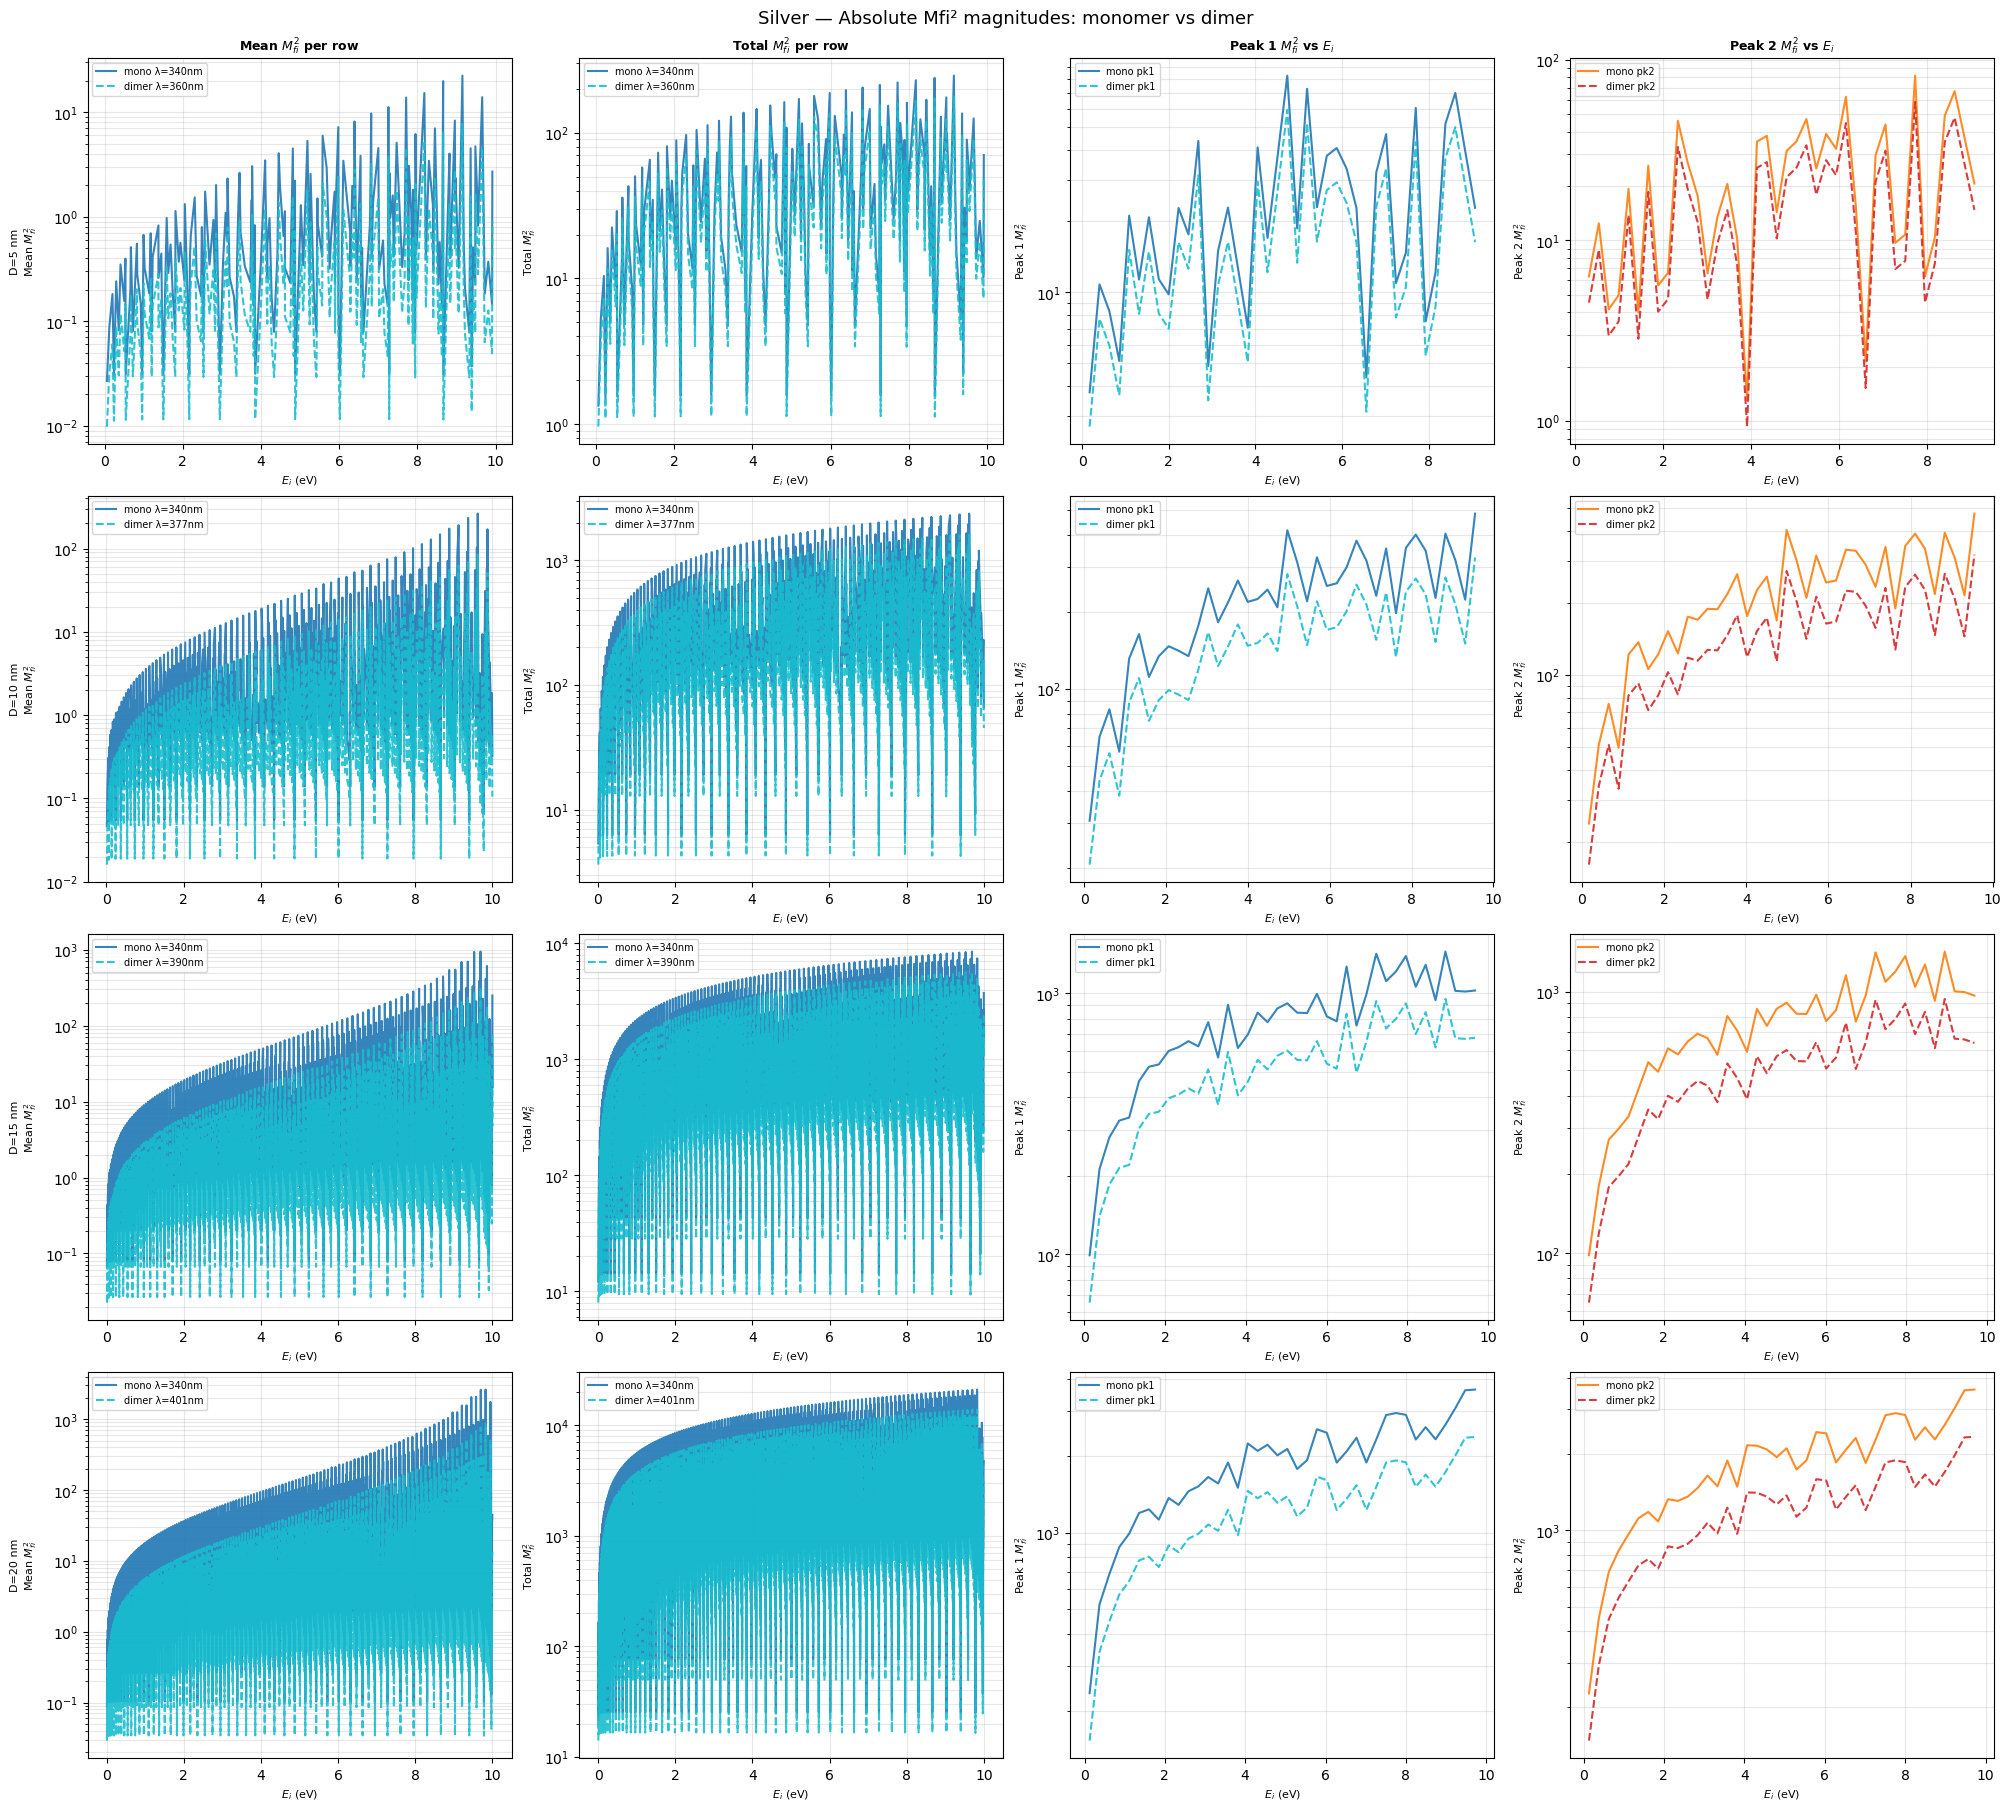


Dimer/Monomer enhancement at top 10% E_i:
  D (nm)     mean Mfi2 ratio    sum Mfi2 ratio
       5               0.339             0.720
      10               0.320             0.681
      15               0.315             0.667
      20               0.313             0.660


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from plytrons.plot_utils import _collapse_equal_energies
from scipy.stats import binned_statistic

# ── helper: compute per-row stats of Mfi2 ────────────────────────────────────
def get_row_stats(Mfi2, E_vals, n_bins=40):
    M = np.asarray(Mfi2, float)
    E = np.asarray(E_vals, float)
    order  = np.argsort(E)
    M_plot, E_u, _ = _collapse_equal_energies(M[order][:, order], E[order], how="sum")

    E_i_vals, mean_row, sum_row, max_row = [], [], [], []
    for idx in range(len(E_u)):
        row = M_plot[idx, :]
        if row.max() == 0:
            continue
        E_i_vals.append(E_u[idx])
        mean_row.append(row[row > 0].mean())
        sum_row.append(row.sum())
        max_row.append(row.max())

    return np.array(E_i_vals), np.array(mean_row), np.array(sum_row), np.array(max_row)

# ── run sweep (reuses get_qw / get_Mfi2 from previous cell) ──────────────────
sweep = {}
for D in DIAMETERS:
    print(f"D = {D} nm ...", end=" ")
    e_states, EF = get_qw(D)

    pos_mono = [np.array([0., 0., 0.])]
    Mfi2_m, E_m, hv_m, lam_m = get_Mfi2(D, pos_mono, e_states, EF)

    gap_nm = 1.0
    sep    = D / 2 + gap_nm / 2
    pos_dim = [np.array([-sep, 0., 0.]), np.array([sep, 0., 0.])]
    Mfi2_d, E_d, hv_d, lam_d = get_Mfi2(D, pos_dim, e_states, EF)

    # also get peak vals from rec
    rec_m, bs_m, eimax_m = run_peak_analysis(Mfi2_m, E_m)
    rec_d, bs_d, eimax_d = run_peak_analysis(Mfi2_d, E_d)

    sweep[D] = dict(
        mono=dict(Mfi2=Mfi2_m, E=E_m, lam=lam_m, rec=rec_m, eimax=eimax_m),
        dimer=dict(Mfi2=Mfi2_d, E=E_d, lam=lam_d, rec=rec_d, eimax=eimax_d),
    )
    print("done")

# ── plot: 4 rows × 4 cols ─────────────────────────────────────────────────────
# cols: [mean Mfi2/row, sum Mfi2/row, peak1 val, peak2 val]  mono vs dimer overlay
fig, axes = plt.subplots(len(DIAMETERS), 4, figsize=(20, 4.5 * len(DIAMETERS)),
                         constrained_layout=True)
fig.suptitle(f"{MATERIAL} — Absolute Mfi² magnitudes: monomer vs dimer", fontsize=13)

col_labels = ["Mean $M_{fi}^2$ per row", "Total $M_{fi}^2$ per row",
              "Peak 1 $M_{fi}^2$ vs $E_i$", "Peak 2 $M_{fi}^2$ vs $E_i$"]
for j, cl in enumerate(col_labels):
    axes[0, j].set_title(cl, fontsize=9, fontweight="bold")

for row_i, D in enumerate(DIAMETERS):
    s = sweep[D]
    axs = axes[row_i]

    for label, key, ls, alpha in [("mono", "mono", "-", 0.9),
                                   ("dimer", "dimer", "--", 0.9)]:
        d = s[key]
        Ei, mean_r, sum_r, max_r = get_row_stats(d["Mfi2"], d["E"])
        col_m = "tab:blue" if key == "mono" else "tab:cyan"
        col_s = "tab:orange" if key == "mono" else "tab:red"

        lbl = f"{label} λ={d['lam']:.0f}nm"

        # col 0 — mean Mfi2 per row
        axs[0].semilogy(Ei, mean_r, ls=ls, lw=1.5, alpha=alpha,
                        color=col_m, label=lbl)

        # col 1 — sum Mfi2 per row
        axs[1].semilogy(Ei, sum_r, ls=ls, lw=1.5, alpha=alpha,
                        color=col_m, label=lbl)

        # cols 2,3 — peak val vs E_i for each rank
        rec = d["rec"]
        if rec is not None:
            for pk_rank, ax_idx, col in [(0, 2, col_m), (1, 3, col_s)]:
                mask = (rec["rank"] == pk_rank) & (rec["E_i"] <= d["eimax"])
                if mask.sum() == 0:
                    continue
                # bin to smooth
                Ei_pk = rec["E_i"][mask]
                val_pk = rec["val"][mask]
                mean_v, edges, _ = binned_statistic(Ei_pk, val_pk, statistic="mean",
                                                    bins=40,
                                                    range=(Ei_pk.min(), Ei_pk.max()))
                ctrs = 0.5 * (edges[:-1] + edges[1:])
                valid = ~np.isnan(mean_v)
                axs[ax_idx].semilogy(ctrs[valid], mean_v[valid], ls=ls, lw=1.5,
                                     alpha=alpha, color=col,
                                     label=f"{label} pk{pk_rank+1}")

    for ax in axs:
        ax.set_xlabel("$E_i$ (eV)", fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3, which="both")

    axs[0].set_ylabel(f"D={D} nm\nMean $M_{{fi}}^2$", fontsize=8)
    axs[1].set_ylabel("Total $M_{fi}^2$", fontsize=8)
    axs[2].set_ylabel("Peak 1 $M_{fi}^2$", fontsize=8)
    axs[3].set_ylabel("Peak 2 $M_{fi}^2$", fontsize=8)

plt.show()

# ── print enhancement ratio at high E_i ──────────────────────────────────────
print("\nDimer/Monomer enhancement at top 10% E_i:")
print(f"{'D (nm)':>8}  {'mean Mfi2 ratio':>18}  {'sum Mfi2 ratio':>16}")
for D in DIAMETERS:
    s = sweep[D]
    cutoff_m = np.percentile(s["mono"]["E"], 90)
    cutoff_d = np.percentile(s["dimer"]["E"], 90)
    _, mean_m, sum_m, _ = get_row_stats(s["mono"]["Mfi2"], s["mono"]["E"])
    _, mean_d, sum_d, _ = get_row_stats(s["dimer"]["Mfi2"], s["dimer"]["E"])
    ratio_mean = mean_d[-int(len(mean_d)*0.1):].mean() / mean_m[-int(len(mean_m)*0.1):].mean()
    ratio_sum  = sum_d[-int(len(sum_d)*0.1):].mean()  / sum_m[-int(len(sum_m)*0.1):].mean()
    print(f"{D:>8}  {ratio_mean:>18.3f}  {ratio_sum:>16.3f}")
